## Example 2e:
Example workflow that trains a flow-matching model to predict the distribution of amplitude and
phase aberration coefficients from a single image (not a z-stack).

Model trains itself using synthetic examples generated from the forwards model on-the-fly, with
the absolute focus position randomly jittered per example so the decoder learns to characterize
aberrations without relying on a precisely known nominal focus. Because a rigid focus shift is
physically the same pupil operator as the m=0 radial phase terms (defocus, spherical, ...), the
jitter offset is *folded into the phase labels*: the model predicts the effective aberration
actually present in the image, rather than being handed labels that contradict it.

Fitting the model amounts to fitting a change-of-variable transformation, conditioned on
the observed image(s), that takes the aberration coefficients from a standard normal
prior to the predicted posterior. This transformation is represented as a velocity vector
field, which is integrated at inference time to sample the actual, predicted, coefficients.

See, e.g., Lipman et al., "Flow matching for generative modeling," arXiv:2210.02747v2 (2023).

In [1]:
import logging
import math
import warnings

import numpy as np
import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning
from matplotlib import pyplot

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config import NoiseConfig, OpticalConfig, PriorConfig, SimulationConfig, TrainingConfig, VelocityConfig, ZernikeConfig
from cynosure.utilities.training_utils import NoValidationBar
from cynosure.zstack_decoding import (
    ZstackSolver_FlowMatching,
    make_object_distribution,
)

#### Simulation setup

In [4]:
# Simulation parameters:
pupil_grid_size = 255
object_grid_size = 31
object_pixel_size = 0.15  # um
rng_seed = 123

# Experimental parameters:
wavelength = 0.510  # um
focal_length = 4.50e3  # um
numerical_aperture = 0.9
medium_index = 1.54
immersion_index = 1.0
bead_diameter = 0.1  # um

# Fitting parameters:
max_phase_order = 6  # max Zernike N
max_amplitude_order = 4  # max Zernike N
z_jitter = 1.0  # um

device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
train_cfg = TrainingConfig(
    learning_rate=1e-3,
    weight_decay=1e-3,
    batch_size=32,
    generator_chunk=4,
    steps_per_epoch=200,
    val_batches=32,
    val_seed=42,
    mixing_warmup_epochs=10,
)
sim_cfg = SimulationConfig(
    pupil_grid_size=pupil_grid_size,
    object_grid_size=object_grid_size,
    object_pixel_size=object_pixel_size,
    ftype=torch.float32,
    ctype=torch.complex64,
)
opt_cfg = OpticalConfig(
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=numerical_aperture,
    aperture_type="fitted",
    medium_index=medium_index,
    immersion_index=immersion_index,
)
phase_cfg = ZernikeConfig(
    max_phase_order,
    allowed_nm=(
        (1, 1), (1, -1),
        (2, -2), (2, 0), (2, 2),
        (3, -3), (3, -1), (3, 1), (3, 3),
        (4, -4), (4, -2), (4, 0), (4, 2), (4, 4),
        (5, -5), (5, -3), (5, -1), (5, 1), (5, 3), (5, 5),
    )
)
amp_cfg = ZernikeConfig(
    max_amplitude_order,
    allowed_nm=(
        (0, 0), (2, 0), (4, 0)
    )
)
noise_cfg = NoiseConfig(
    min_photons=100_000,
    max_photons=1_000_000,
    max_background=1_000,
    read_noise=10,
)
vel_cfg = VelocityConfig(
    time_embedding_dims=64,
    hidden_dims=(256, 256, 256),
    is_residual=True,
    residual_dims=256,
    num_sample_steps=50,
)

In [6]:
object_distrib = make_object_distribution(sim_cfg.object_grid_size, sim_cfg.object_pixel_size, bead_diameter)
phase_prior = PriorConfig(0.05, 1)
amp_prior = PriorConfig(0.05, 2)

#### Solver setup and training

In [7]:
pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_FlowMatching(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    vel_cfg=vel_cfg,
    object_distribution=object_distrib,
    z_objective=torch.zeros(1),
    z_jitter=z_jitter,
    noise_cfg=noise_cfg,
    hidden_channels=(8, 8),
    embedding_dims=32,
)
solver = solver.to(device)

Seed set to 123


In [8]:
trainer = pl.Trainer(
    max_epochs=80,
    accelerator=device,
    log_every_n_steps=50,
    callbacks=[NoValidationBar()],
)
trainer.fit(solver)

Sanity Checking: |                                                                              | 0/? [00:00<?…

Training: |                                                                                     | 0/? [00:00<?…

#### Sanity checking the results

In [9]:
batch_size = 8
num_samples = 256
images, phase_coefs, amp_coefs = solver.create_examples(batch_size)
pred_phase_coefs, pred_amp_coefs = solver.predict_samples(images, num_samples)
pred_images = solver.simulate_normalized_stacks(
    pred_phase_coefs.reshape(batch_size*num_samples, -1),
    pred_amp_coefs.reshape(batch_size*num_samples, -1),
).unflatten(0, (batch_size, num_samples))  # [batch_size, num_samples, num_z, H, W]

In [10]:
kept_labels = solver.nonpiston_labels
coefs = solver.join_phase_amp(phase_coefs, amp_coefs)  # [batch_size, num_coefs]
pred_coefs = solver.join_phase_amp(pred_phase_coefs, pred_amp_coefs)  # [batch_size, num_samples, num_coefs]

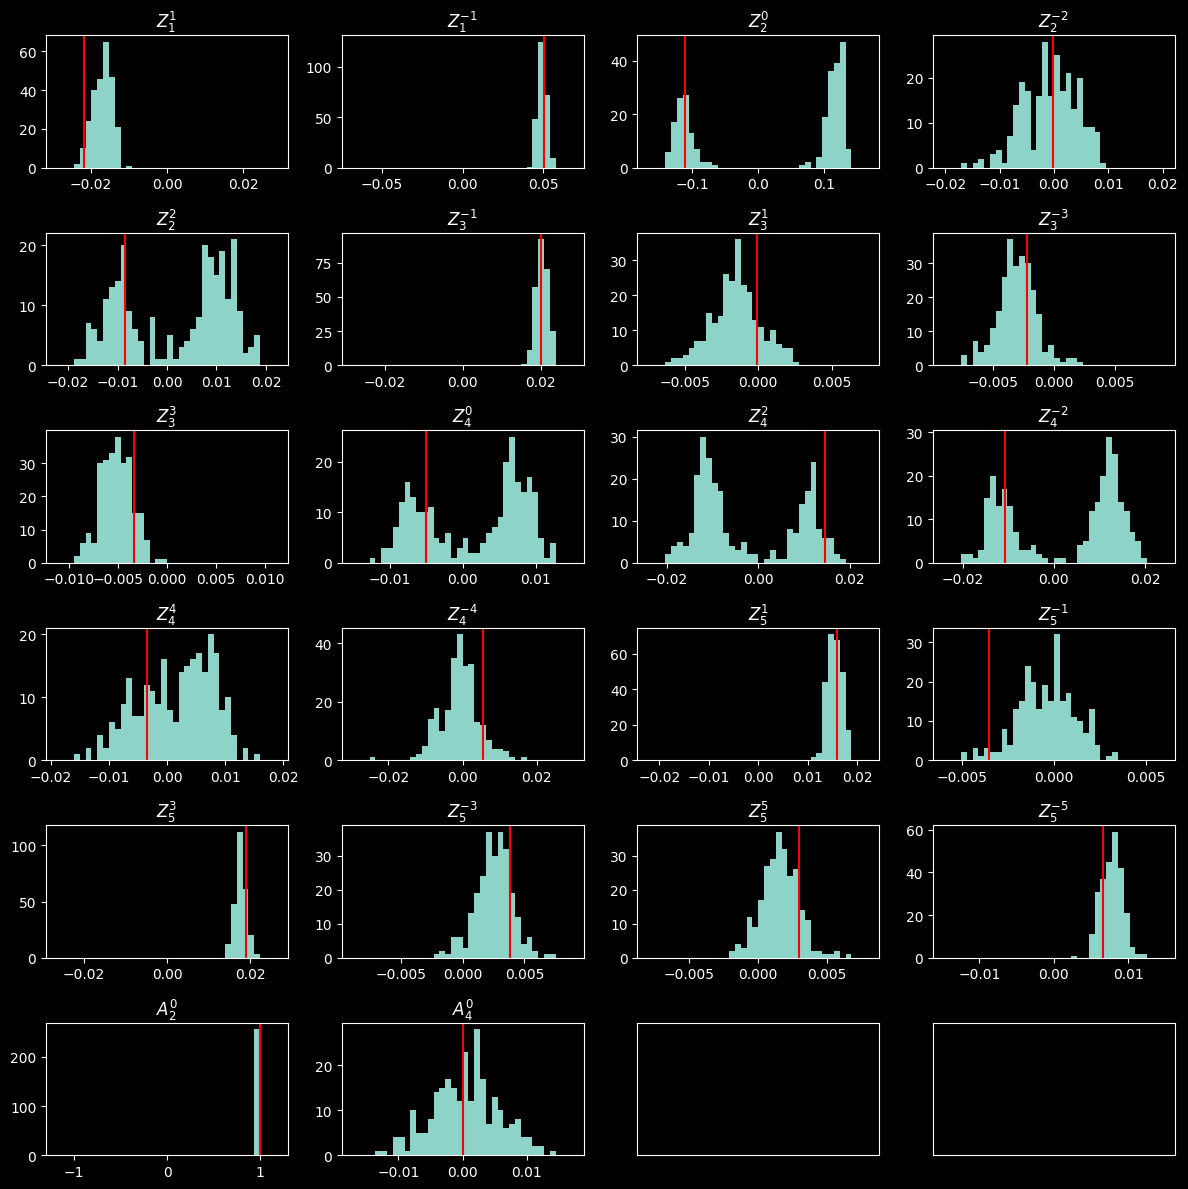

In [11]:
num_plots = solver.num_nonpiston_coefs
panel_size = 2
aspect_ratio = 1.5
num_cols = 4
num_rows = int(math.ceil(num_plots / num_cols))

bidx = 0

figsize = (num_cols * panel_size * aspect_ratio, num_rows * panel_size)
fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_plots:
        lbl = kept_labels[i]
        target = coefs[bidx, i].numpy(force=True)
        pred_distrib = pred_coefs[bidx, :, i].numpy(force=True)
        bound = np.max(np.abs(pred_distrib))
        _ = ax.hist(pred_distrib, range=(-bound, bound), bins=32)
        ax.axvline(target, color="r")
        ax.set_xlim(-bound*1.3, bound*1.3)
        ax.set_title(lbl)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()


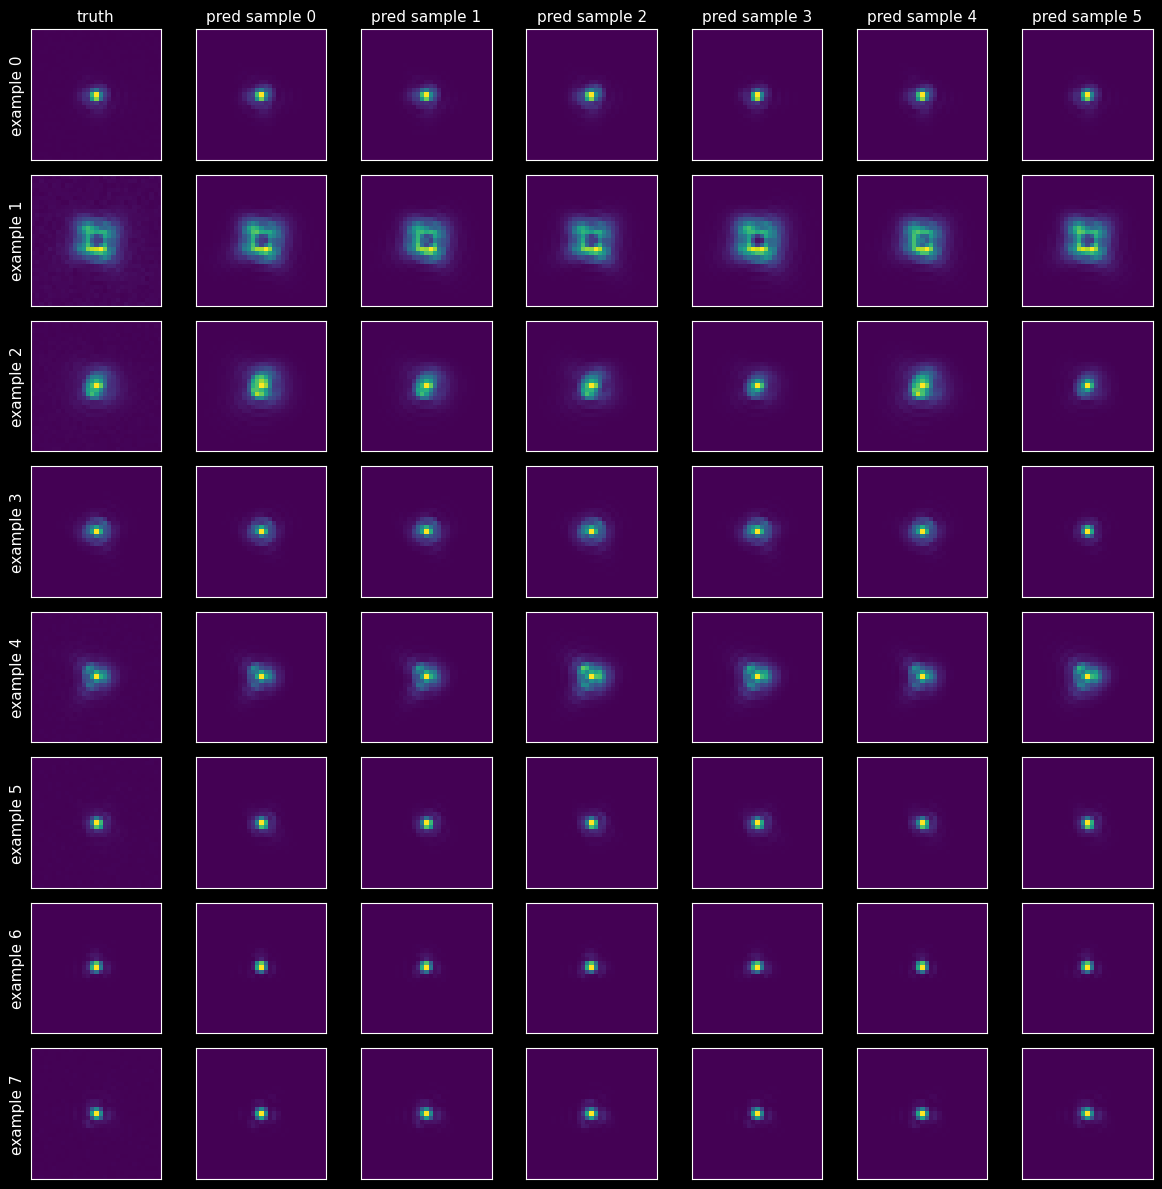

In [12]:
num_samples_to_show = 6
panel_size = 2
fig, axarr = pyplot.subplots(batch_size, 1+num_samples_to_show, figsize=(num_samples_to_show*panel_size, num_samples_to_show*panel_size))
for bidx in range(batch_size):
    axarr[bidx, 0].imshow(images[bidx, 0].numpy(force=True))
    for i in range(num_samples_to_show):
        axarr[bidx, i+1].imshow(pred_images[bidx, i, 0].numpy(force=True))

for ax in axarr.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
for bidx in range(batch_size):
    axarr[bidx, 0].set_ylabel(f"example {bidx}", size=11)
axarr[0, 0].set_title("truth", size=11)
for i in range(num_samples_to_show):
    axarr[0, i+1].set_title(f"pred sample {i}", size=11)
fig.tight_layout()